In [52]:
!pip install 'sunpy[all]' 'numpy<1.26' natsort xarray torch codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 11.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 17.1 MB/s eta 0:00:00a 0:00:01


In [54]:
import numpy as np
from natsort import natsorted
import xarray as xr

import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as cm
from codecarbon import track_emissions

# Load Data

# Inspect Data

Download file locally to your computer from https://zenodo.org/records/15143847/files/all128.nc

Put it in now Google Drive next!

In [2]:
ds = xr.open_dataset('/cephfs/users/sfroese/all128.nc')

In [3]:
ds.channel

<xarray.DataArray 'channel' (channel: 9)> Size: 72B
array(['131A', '1600A', '1700A', '171A', '193A', '211A', '304A', '335A', '94A'],
      dtype=object)
Coordinates:
  * channel  (channel) object 72B '131A' '1600A' '1700A' ... '304A' '335A' '94A'

In [4]:
selected_channel = ds['DN'].sel(channel='171A')
selected_channel

<xarray.DataArray 'DN' (time: 6130, x: 128, y: 128)> Size: 402MB
[100433920 values with dtype=float32]
Coordinates:
  * time     (time) int32 25kB 0 1 2 3 4 5 6 ... 6124 6125 6126 6127 6128 6129
  * x        (x) int32 512B 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * y        (y) int32 512B 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
    channel  <U4 16B '171A'

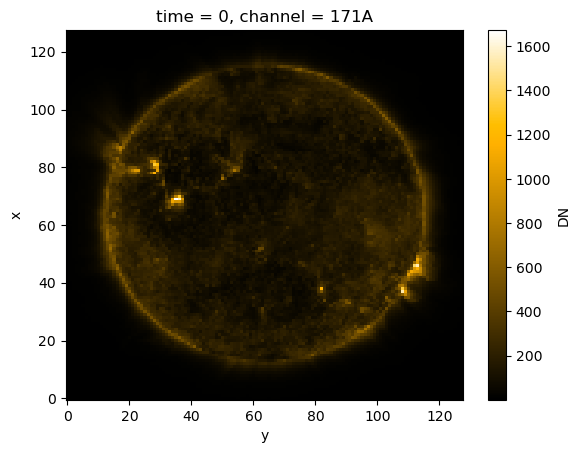

In [5]:
img = selected_channel.isel(time=0)
cmap = plt.get_cmap('sdoaia171')
img.plot(cmap=cmap)


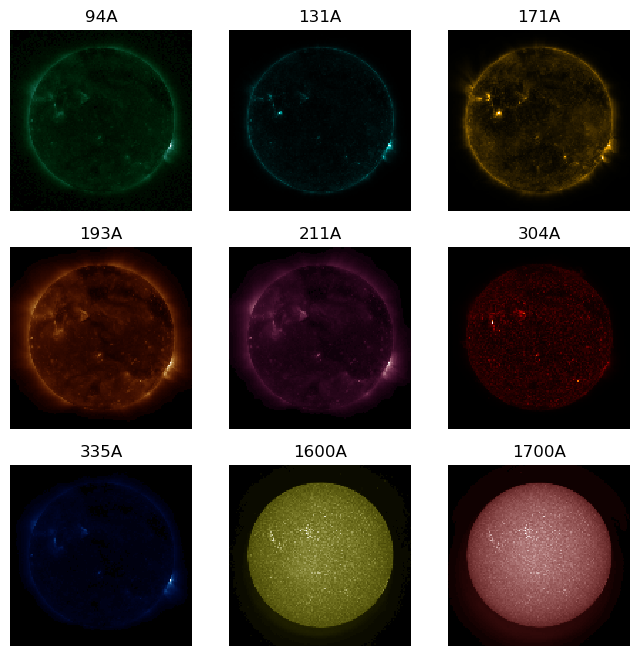

In [6]:
keys = natsorted(ds['channel'].data)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, key in zip(axes.ravel(), keys):
    data = ds['DN'].sel(channel=key).isel(time=0)
    cmap = plt.get_cmap(f'sdoaia{key[:-1]}')
    im = data.plot(cmap=cmap, ax=ax, add_colorbar=False)
    ax.set_title(key)
    ax.axis('off')

plt.show()

# Fun Times

In [7]:
!pip install torch_lr_finder torchvision

## Create Dataset

In [8]:
from torch.utils.data import Dataset, random_split, DataLoader
import torch
from torchvision import transforms
from torch import nn
from torch_lr_finder import LRFinder
import random

/scratch/sfroese/envs/solar/lib/python3.10/site-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [9]:
class SolarDataset(Dataset):
    def __init__(self, xds, input_transform=None, pair_transform=None):
        self.dataset = xds
        self.input_transform = input_transform
        self.pair_transform = pair_transform
        self.X = self.dataset['DN'].sel(channel=['94A'])
        self.Y = self.dataset['DN'].sel(channel=['131A', '171A', '193A', '211A', '304A', '335A', '1600A', '1700A'])


    def __len__(self):
        return self.dataset['DN'].time.shape[0]

    def __getitem__(self, idx):
        x = self.X.isel(time=idx).to_numpy()
        y = self.Y.isel(time=idx).to_numpy()

        x_t = torch.tensor(x)
        y_t = torch.tensor(y)

        if self.input_transform:
            x_t = self.input_transform(x_t)
        if self.pair_transform:
            x_t, y_t = self.pair_transform(x_t, y_t)
        
        return x_t, y_t

In [10]:
# Assuming xds is your xarray dataset
channel_data = ds['DN'].sel(channel='94A')
mean_value = channel_data.mean().item()
std_value = channel_data.std().item()
print("Mean:", mean_value, "Std:", std_value)

Mean: 0.5850173830986023 Std: 1.3549635410308838


In [11]:
transform = transforms.Normalize(mean=[mean_value], std=[std_value])

In [12]:
class RandomRotation:
    def __init__(self, deg):
        self.deg = deg

    def __call__(self, x, y):
        angle = random.uniform(-self.deg, self.deg)
        x_rot = transforms.functional.rotate(x, angle, fill=0)
        y_rot = transforms.functional.rotate(y, angle, fill=0)
        return x_rot, y_rot

rot_transform = RandomRotation(deg=30)

In [13]:
# transform = None
dataset = SolarDataset(ds, input_transform=transform, pair_transform=rot_transform)
train_set, test_set, val_set = random_split(dataset, [0.7, 0.15, 0.15])

In [14]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=True)

In [15]:
train_features, train_target = next(iter(train_loader))

In [16]:
train_features.shape

torch.Size([64, 1, 128, 128])

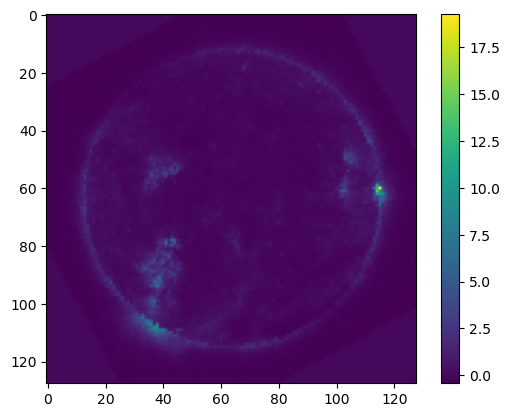

In [17]:
plt.imshow(train_features[0][0])
plt.colorbar()

In [18]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [23]:
class ResNetBlock(nn.Module):
  def __init__(self, channels):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(channels)
    self.relu = nn.ReLU()
    self.conv2 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(channels)

  def forward(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out += x
    out = self.relu(out)
    return out

class CNN(nn.Module):
    def __init__(self, in_channels=1, out_channels=8, num_res_blocks=3, num_res_blocks_refine=3):
        super().__init__()
        self.cnn_stack = nn.Sequential(
                  nn.Conv2d(in_channels=in_channels, out_channels=128, kernel_size=7, stride=2, padding=3, bias=False),
                  nn.BatchNorm2d(128),
                  nn.ReLU(),
                  nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )   
        res_blocks = []
        for _ in range(num_res_blocks):
          res_blocks.append(ResNetBlock(128))
        self.res_stack = nn.Sequential(*res_blocks)

        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        res_block_refine = []
        for _ in range(num_res_blocks_refine):
          res_block_refine.append(ResNetBlock(128))
        self.res_stack_refine = nn.Sequential(*res_block_refine)

        self.final = nn.Conv2d(in_channels=128, out_channels=out_channels, kernel_size=3, stride=1, padding=1, bias=False)
    
        # self.final = nn.Sequential(
        #   nn.Conv2d(in_channels=128, out_channels=out_channels, kernel_size=3, stride=1, padding=1),
        #   nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False)
        # )
        
        # self.cnn_stack = nn.Sequential(
        #     nn.Conv2d(in_channels=1, out_channels=128, kernel_size=7, stride=2, padding=3),
        #     nn.BatchNorm2d(128),
        #     nn.ReLU(),
        #     nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        #     nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
        #     nn.BatchNorm2d(128),
        #     nn.ReLU(),
        #     nn.Conv2d(in_channels=128, out_channels=8, kernel_size=3, stride=1, padding=1),
        #     nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False)
        # )


    def forward(self, x):
        x = self.cnn_stack(x)
        x = self.res_stack(x)
        x = self.upsample(x)
        x = self.res_stack_refine(x)
        x = self.final(x)
        return x

In [25]:
model = CNN(num_res_blocks=3, num_res_blocks_refine=1).to(device)
print(model)

CNN(
  (cnn_stack): Sequential(
    (0): Conv2d(1, 128, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (res_stack): Sequential(
    (0): ResNetBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResNetBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
 

In [26]:
X = train_features.to(device=device)
y = model(X)
y.shape

torch.Size([64, 8, 128, 128])

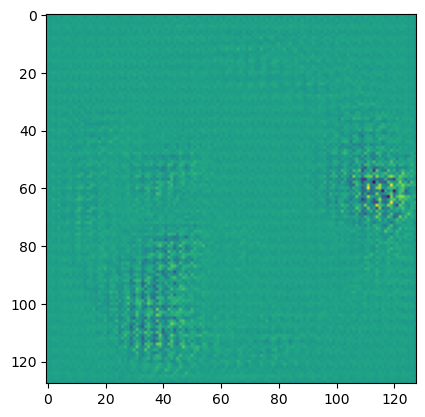

In [27]:
plt.imshow(y[0,0].cpu().detach().numpy())

In [56]:
@track_emissions(project_name='solar')
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model.train()
    batch_losses = 0
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X.to(device=device))
        loss = loss_fn(pred, y.to(device=device))

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # if batch % 100 == 0:
        #     loss = loss.item()
        #     print(f"train loss: {loss:>7f}")
        batch_losses += loss.item()
    return batch_losses / len(dataloader)

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X.to(device=device))
            test_loss += loss_fn(pred, y.to(device=device)).item()

    test_loss /= num_batches
    print(f"Test Error: \n Avg test loss: {test_loss:>8f} \n")
    return test_loss

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 2.31E-02


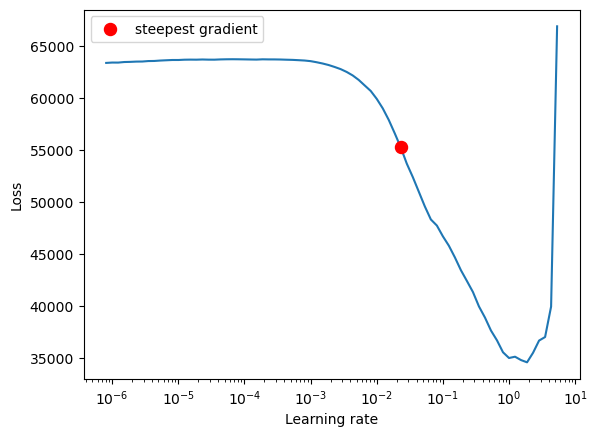

In [29]:
model = CNN(num_res_blocks=3, num_res_blocks_refine=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-7, weight_decay=1e-5)
lr_finder = LRFinder(model, optimizer, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=100, num_iter=100)
lr_finder.plot() # to inspect the loss-learning rate graph
lr_finder.reset() # to reset the model and optimizer to their initial state

In [ ]:
model = CNN(num_res_blocks=3, num_res_blocks_refine=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2.31e-2, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, threshold=1e-2)
loss_fn = nn.MSELoss()
epochs = 100
train_losses = []
test_losses = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_losses.append(train_loop(train_loader, model, loss_fn, optimizer))
    test_loss = test_loop(test_loader, model, loss_fn)
    test_losses.append(test_loss)
    scheduler.step(test_loss)
    current_lr = scheduler.get_last_lr()
    print("\t Current learning rate:", current_lr)
print("Done!")

[codecarbon INFO @ 14:26:10] [setup] RAM Tracking...
[codecarbon INFO @ 14:26:10] [setup] CPU Tracking...
[codecarbon WARNING @ 14:26:10] No CPU tracking mode found. Falling back on CPU constant mode. 
 Linux OS detected: Please ensure RAPL files exist at \sys\class\powercap\intel-rapl to measure CPU

[codecarbon WARNING @ 14:26:10] We saw that you have a Intel(R) Xeon(R) CPU E5-2680 v3 @ 2.50GHz but we don't know it. Please contact us.


Epoch 1
-------------------------------


[codecarbon INFO @ 14:26:10] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU E5-2680 v3 @ 2.50GHz
[codecarbon INFO @ 14:26:10] [setup] GPU Tracking...
[codecarbon INFO @ 14:26:10] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 14:26:10] >>> Tracker's metadata:
[codecarbon INFO @ 14:26:10]   Platform system: Linux-5.14.0-503.22.1.el9_5.x86_64-x86_64-with-glibc2.34
[codecarbon INFO @ 14:26:10]   Python version: 3.10.16
[codecarbon INFO @ 14:26:10]   CodeCarbon version: 2.8.3
[codecarbon INFO @ 14:26:10]   Available RAM : 125.272 GB
[codecarbon INFO @ 14:26:10]   CPU count: 48
[codecarbon INFO @ 14:26:10]   CPU model: Intel(R) Xeon(R) CPU E5-2680 v3 @ 2.50GHz
[codecarbon INFO @ 14:26:10]   GPU count: 2
[codecarbon INFO @ 14:26:10]   GPU model: 2 x Tesla P40
[codecarbon INFO @ 14:26:14] Saving emissions data to file /net/apphome/home/sfroese/Challenges/solar/emissions.csv
[codecarbon INFO @ 14:26:29] Energy consumed for RAM : 0.000196 kWh. RAM Power : 46.97710132598877 W
[c

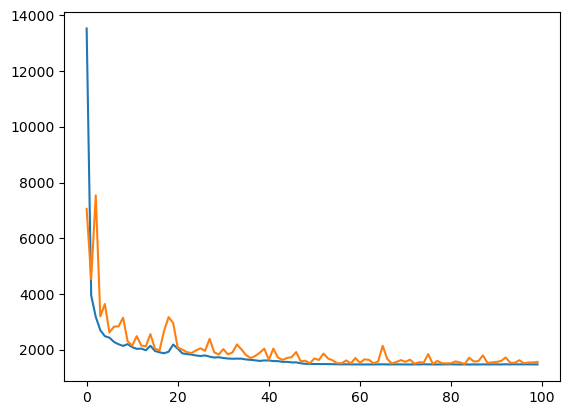

In [31]:
plt.plot(train_losses)
plt.plot(test_losses)

In [32]:

def validate_model(model, val_loader, device):
    """
    Validate the model on the entire validation set using L1 loss.
    
    Args:
        model (torch.nn.Module): Trained PyTorch model.
        val_loader (torch.utils.data.DataLoader): DataLoader for validation data.
        device (torch.device): Device to perform computation on (e.g., 'cuda' or 'cpu').
        
    Returns:
        float: Average L1 loss over the validation set.
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0

    
    criterion = torch.nn.MSELoss()
    
    with torch.no_grad():  # Disable gradient computation for validation
        for inputs, targets in val_loader:
            # Move data to the appropriate device
            inputs = inputs.to(device)
            targets = targets.to(device)

            
            # Forward pass: get predictions from the model
            outputs = model(inputs)
            
            # Compute the loss. With reduction='sum', the loss is summed over the batch.
            loss = criterion(outputs, targets)
            
            # Count the number of samples in this batch
            batch_size = inputs.size(0)
            total_loss += loss.item()
    
    # If you used reduction 'sum', normalize by the total number of samples to get the average loss.
    avg_loss = total_loss / len(val_loader)
    print(f"Validation L1 Loss: {avg_loss:.4f}")
    return avg_loss


avg_loss = validate_model(model, val_loader, device)

Validation L1 Loss: 1541.7932


In [33]:
validate_model(model, test_loader, device)

Validation L1 Loss: 1560.3008


1560.3007568359376

In [34]:
val_features, val_target = next(iter(val_loader))

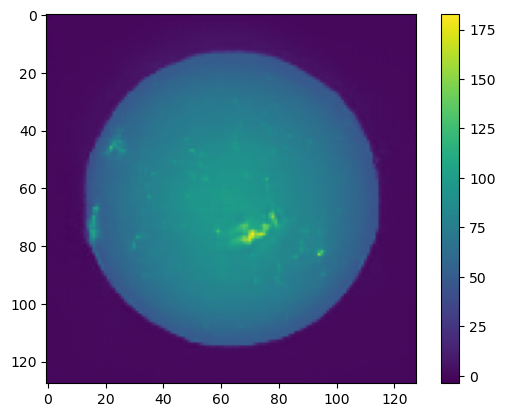

In [50]:
img_idx=2
ch_idx = 6
plt.imshow(model(val_features.to(device))[img_idx][ch_idx].cpu().detach())
plt.colorbar()

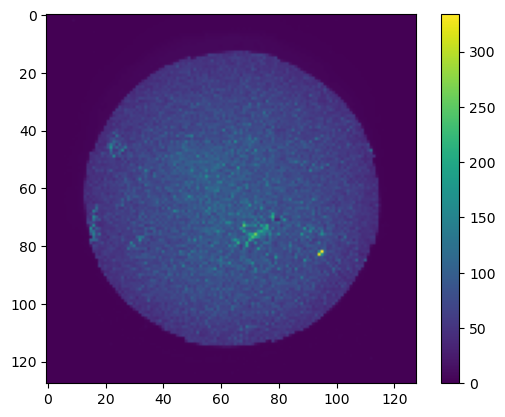

In [51]:
plt.imshow(val_target[img_idx][ch_idx])
plt.colorbar()